In [3]:
# analisis_distrital_posicion_en_base.py

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from pathlib import Path

In [4]:
# =========================================================
# 1. CONFIGURACION
# =========================================================

# Cambia esta ruta si tus archivos no estan en la misma carpeta del script
base_path = Path("/Users/karlavega/Documents/GitHub/Forest_Peru/Scrapping/data")

archivos = {
    2006: "distrital_2006.csv",
    2010: "distrital_2010.csv",
    2014: "distrital_2014.csv",
    2018: "distrital_2018.csv",
    2022: "distrital_2022.csv",
}

In [6]:
# =========================================================
# 2. FUNCION PARA LEER CSV
# =========================================================

def leer_csv_seguro(path_archivo):
    """
    Intenta leer el CSV con utf-8; si falla, intenta latin1.
    """
    try:
        df = pd.read_csv(path_archivo)
    except UnicodeDecodeError:
        df = pd.read_csv(path_archivo, encoding="latin1")
    return df

In [7]:
# =========================================================
# 3. CARGAR Y APILAR BASES
# =========================================================

lista_dfs = []

for year, nombre_archivo in archivos.items():
    ruta = base_path / nombre_archivo
    df_temp = leer_csv_seguro(ruta)

    # Estandarizar nombres de columnas
    df_temp.columns = df_temp.columns.str.strip().str.lower()

    # Agregar año
    df_temp["year"] = year

    # Guardar el orden original del archivo completo
    # Esto permite reconstruir la posicion tal como aparece en la base
    df_temp["orden_original_archivo"] = np.arange(1, len(df_temp) + 1)

    lista_dfs.append(df_temp)

df = pd.concat(lista_dfs, ignore_index=True)

In [8]:
# =========================================================
# 4. LIMPIEZA BASICA
# =========================================================

# Quitar espacios en variables de texto
columnas_texto = ["region", "provincia", "distrito", "organizacion_politica"]
for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# Convertir variables numericas
df["ubigeo"] = pd.to_numeric(df["ubigeo"], errors="coerce")
df["total_votos"] = pd.to_numeric(df["total_votos"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Eliminar filas con informacion minima faltante
df = df.dropna(subset=["ubigeo", "organizacion_politica", "year"]).copy()

In [9]:
# =========================================================
# 5. CREAR POSICION SEGUN ORDEN EN LA BASE
# =========================================================
# La posicion se define dentro de cada distrito-año
# respetando el orden original de aparicion en el archivo

df = df.sort_values(["year", "ubigeo", "orden_original_archivo"]).copy()

df["posicion"] = (
    df.groupby(["year", "ubigeo"], sort=False)
      .cumcount() + 1
)


In [10]:
# =========================================================
# 6. CREAR VARIABLE DEPENDIENTE: GANA
# =========================================================
# Gana = 1 si tiene el mayor total_votos dentro del distrito-año

# Opcion 1: permite empates
max_votos = df.groupby(["year", "ubigeo"])["total_votos"].transform("max")
df["gana"] = (df["total_votos"] == max_votos).astype(int)

# Si prefieres forzar un solo ganador por distrito-año, usa esto en vez de arriba:
# df["rank_votos"] = (
#     df.groupby(["year", "ubigeo"])["total_votos"]
#       .rank(method="first", ascending=False)
# )
# df["gana"] = (df["rank_votos"] == 1).astype(int)

In [11]:
# =========================================================
# 7. CREAR DUMMY PARTIDO / MOVIMIENTO
# =========================================================
# Regla simple: si el nombre contiene "MOVIMIENTO", es movimiento

texto_org = df["organizacion_politica"].str.upper()

df["es_movimiento"] = texto_org.str.contains("MOVIMIENTO", na=False).astype(int)
df["tipo_org"] = np.where(df["es_movimiento"] == 1, "movimiento", "partido")


In [12]:
# =========================================================
# 8. FILTROS SEGUN LAS INSTRUCCIONES
# =========================================================

# 8.1. Mantener solo posiciones hasta 15
df = df[df["posicion"] <= 15].copy()

# 8.2. Minimo 30 observaciones por posicion-año
conteos_posicion_year = (
    df.groupby(["year", "posicion"])
      .size()
      .reset_index(name="n_obs")
)

df = df.merge(conteos_posicion_year, on=["year", "posicion"], how="left")
df = df[df["n_obs"] >= 30].copy()


In [13]:
# =========================================================
# 9. REVISIONES RAPIDAS
# =========================================================

print("=" * 80)
print("DIMENSIONES DE LA BASE FINAL")
print("=" * 80)
print(df.shape)

print("\n" + "=" * 80)
print("COLUMNAS DISPONIBLES")
print("=" * 80)
print(df.columns.tolist())

print("\n" + "=" * 80)
print("PRIMERAS FILAS PARA REVISAR POSICION DENTRO DE DISTRITO-AÑO")
print("=" * 80)
revision = df[
    ["year", "ubigeo", "distrito", "organizacion_politica", "posicion", "total_votos", "gana"]
].sort_values(["year", "ubigeo", "posicion"])

print(revision.head(30).to_string(index=False))

print("\n" + "=" * 80)
print("OBSERVACIONES POR YEAR Y POSICION")
print("=" * 80)
print(
    df.groupby(["year", "posicion"])
      .size()
      .reset_index(name="n")
      .sort_values(["year", "posicion"])
      .to_string(index=False)
)

DIMENSIONES DE LA BASE FINAL
(51862, 13)

COLUMNAS DISPONIBLES
['ubigeo', 'region', 'provincia', 'distrito', 'organizacion_politica', 'total_votos', 'year', 'orden_original_archivo', 'posicion', 'gana', 'es_movimiento', 'tipo_org', 'n_obs']

PRIMERAS FILAS PARA REVISAR POSICION DENTRO DE DISTRITO-AÑO
 year  ubigeo    distrito                          organizacion_politica  posicion  total_votos  gana
 2006   10102    ASUNCION                                 ACCION POPULAR         1           35     0
 2006   10102    ASUNCION                             FUERZA DEMOCRATICA         2           88     1
 2006   10102    ASUNCION MOVIMIENTO REGIONAL AMAZONENSE UNIDOS AL CAMPO         3           50     0
 2006   10102    ASUNCION                        PARTIDO APRISTA PERUANO         4           23     0
 2006   10103      BALSAS                                 ACCION POPULAR         1           41     0
 2006   10103      BALSAS             AGRUPACION INDEPENDIENTE SI CUMPLE         2    

In [14]:
# =========================================================
# 10. MODELO BASE
# =========================================================
# LPM: gana ~ posicion + FE distrito + FE tiempo
# FE distrito = C(ubigeo)
# FE año      = C(year)
# Errores cluster por distrito

modelo_base = smf.ols(
    formula="gana ~ posicion + C(ubigeo) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["ubigeo"]}
)

print("\n" + "=" * 80)
print("MODELO BASE")
print("gana ~ posicion + C(ubigeo) + C(year)")
print("=" * 80)
print(modelo_base.summary())



MODELO BASE
gana ~ posicion + C(ubigeo) + C(year)
                            OLS Regression Results                            
Dep. Variable:                   gana   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                -2.111e+13
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               1.00
Time:                        23:54:03   Log-Likelihood:                -21508.
No. Observations:               51862   AIC:                         4.641e+04
Df Residuals:                   50164   BIC:                         6.145e+04
Df Model:                        1697                                         
Covariance Type:              cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1697, but rank is 4
  warnings.warn('covariance of constraints does not have full '


In [15]:
# =========================================================
# 11. MODELO CON INTERACCION
# =========================================================
# gana ~ posicion * es_movimiento + FE distrito + FE año

modelo_interaccion = smf.ols(
    formula="gana ~ posicion * es_movimiento + C(ubigeo) + C(year)",
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["ubigeo"]}
)

print("\n" + "=" * 80)
print("MODELO CON INTERACCION")
print("gana ~ posicion * es_movimiento + C(ubigeo) + C(year)")
print("=" * 80)
print(modelo_interaccion.summary())


MODELO CON INTERACCION
gana ~ posicion * es_movimiento + C(ubigeo) + C(year)
                            OLS Regression Results                            
Dep. Variable:                   gana   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                -3.563e+11
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               1.00
Time:                        23:54:25   Log-Likelihood:                -21474.
No. Observations:               51862   AIC:                         4.635e+04
Df Residuals:                   50162   BIC:                         6.140e+04
Df Model:                        1699                                         
Covariance Type:              cluster                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1699, but rank is 6
  warnings.warn('covariance of constraints does not have full '


In [16]:
# =========================================================
# 12. TABLAS DE COEFICIENTES
# =========================================================

tabla_base = pd.DataFrame({
    "variable": modelo_base.params.index,
    "coef": modelo_base.params.values,
    "se": modelo_base.bse.values,
    "pvalue": modelo_base.pvalues.values
})

tabla_interaccion = pd.DataFrame({
    "variable": modelo_interaccion.params.index,
    "coef": modelo_interaccion.params.values,
    "se": modelo_interaccion.bse.values,
    "pvalue": modelo_interaccion.pvalues.values
})

In [17]:
# =========================================================
# 13. RESUMEN DESCRIPTIVO
# =========================================================

resumen = (
    df.groupby(["year", "posicion", "tipo_org"], as_index=False)
      .agg(
          n=("gana", "size"),
          prob_ganar=("gana", "mean"),
          votos_promedio=("total_votos", "mean")
      )
)


In [18]:
# =========================================================
# 14. EXPORTAR RESULTADOS
# =========================================================

df.to_csv("base_final_con_posicion.csv", index=False)
tabla_base.to_csv("resultados_modelo_base.csv", index=False)
tabla_interaccion.to_csv("resultados_modelo_interaccion.csv", index=False)
resumen.to_csv("resumen_posicion_tipo.csv", index=False)

print("\n" + "=" * 80)
print("ARCHIVOS GUARDADOS")
print("=" * 80)
print("- base_final_con_posicion.csv")
print("- resultados_modelo_base.csv")
print("- resultados_modelo_interaccion.csv")
print("- resumen_posicion_tipo.csv")


ARCHIVOS GUARDADOS
- base_final_con_posicion.csv
- resultados_modelo_base.csv
- resultados_modelo_interaccion.csv
- resumen_posicion_tipo.csv


In [19]:
print("\n--- MODELO BASE ---")
print(tabla_base[tabla_base["variable"].str.contains("posicion", na=False)].to_string(index=False))

print("\n--- MODELO INTERACCION ---")
print(tabla_interaccion[
    tabla_interaccion["variable"].str.contains("posicion|es_movimiento", na=False)
].to_string(index=False))

print("\n--- RESUMEN DESCRIPTIVO ---")
print(resumen.head(30).to_string(index=False))


--- MODELO BASE ---
variable      coef       se       pvalue
posicion -0.006252 0.000738 2.476348e-17

--- MODELO INTERACCION ---
              variable      coef       se       pvalue
              posicion -0.005217 0.000745 2.484726e-12
         es_movimiento  0.049757 0.011599 1.788400e-05
posicion:es_movimiento -0.004294 0.002351 6.773454e-02

--- RESUMEN DESCRIPTIVO ---
 year  posicion   tipo_org    n  prob_ganar  votos_promedio
 2006         1 movimiento   90    0.255556      283.055556
 2006         1    partido 1547    0.166128      454.438268
 2006         2 movimiento  270    0.185185      300.318519
 2006         2    partido 1367    0.194587      748.629115
 2006         3 movimiento  385    0.166234      268.381818
 2006         3    partido 1232    0.198864      948.484578
 2006         4 movimiento  315    0.149206      330.834921
 2006         4    partido 1207    0.173985      663.879039
 2006         5 movimiento  218    0.110092      508.178899
 2006         5    p

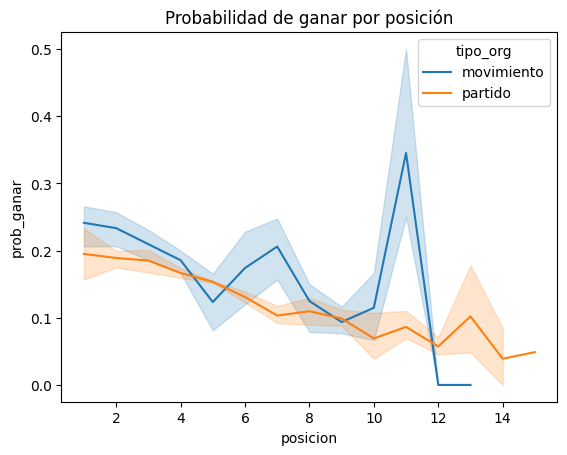

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.lineplot(data=resumen, x="posicion", y="prob_ganar", hue="tipo_org")
plt.title("Probabilidad de ganar por posición")
plt.show()

In [21]:
import pandas as pd
def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.1:
        return "*"
    else:
        return ""

def format_coef(row):
    return f"{row['coef']:.4f}{stars(row['pvalue'])} ({row['se']:.4f})"

tabla_latex = pd.DataFrame({
    "Variable": [
        "Posición",
        "Movimiento",
        "Posición × Movimiento"
    ],
    "Modelo (1)": [
        format_coef(tabla_base[tabla_base["variable"]=="posicion"].iloc[0]),
        "",
        ""
    ],
    "Modelo (2)": [
        format_coef(tabla_interaccion[tabla_interaccion["variable"]=="posicion"].iloc[0]),
        format_coef(tabla_interaccion[tabla_interaccion["variable"]=="es_movimiento"].iloc[0]),
        format_coef(tabla_interaccion[tabla_interaccion["variable"]=="posicion:es_movimiento"].iloc[0])
    ]
})

print(tabla_latex.to_latex(index=False, escape=False))

\begin{tabular}{lll}
\toprule
Variable & Modelo (1) & Modelo (2) \\
\midrule
Posición & -0.0063*** (0.0007) & -0.0052*** (0.0007) \\
Movimiento &  & 0.0498*** (0.0116) \\
Posición × Movimiento &  & -0.0043* (0.0024) \\
\bottomrule
\end{tabular}



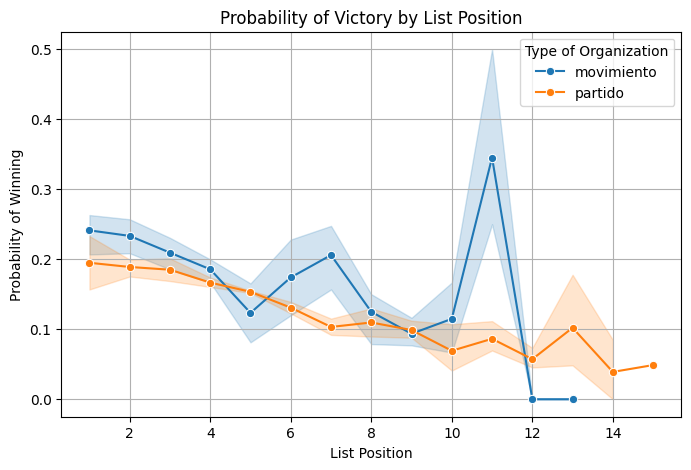

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.lineplot(
    data=resumen,
    x="posicion",              # keep if your dataframe is in Spanish
    y="prob_ganar",            # keep if your dataframe is in Spanish
    hue="tipo_org",
    marker="o"
)

plt.xlabel("List Position")
plt.ylabel("Probability of Winning")
plt.title("Probability of Victory by List Position")
plt.legend(title="Type of Organization")
plt.grid(True)

plt.savefig("figure_position.png", dpi=300, bbox_inches="tight")
plt.show()